# Librerias


In [ ]:
!pip install rasterio tqdm --quiet
!pip install rasterio numba tqdm --quiet
import os, time, multiprocessing
import numpy as np
import rasterio
from rasterio.errors import RasterioIOError
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from numba import njit, prange
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from numba import njit, prange


In [ ]:
from pathlib import Path
import os

DATASET_PATH = Path("/kaggle")

for root, dirs, files in os.walk(DATASET_PATH):
    nivel = root.replace(str(DATASET_PATH), '').count(os.sep)
    if nivel > 4:          # no bajar demasiado
        dirs.clear()
        continue
    sangria = "  " * nivel
    print(f"{sangria}📁 {os.path.basename(root)}/")
    for f in files[:5]:
        print(f"{sangria}   📄 {f}")
    if len(files) > 5:
        print(f"{sangria}   ... +{len(files)-5} archivos más")

📁 kaggle/
  📁 input/
    📁 sentinel-2-satellite-imagery/
      📁 sentinel_2/
        📁 ds/
      📁 EuroSAT/
        📁 2750/


KeyboardInterrupt: 

In [ ]:
# Explorar ambas carpetas
for carpeta in [
    "/kaggle/input/sentinel-2-satellite-imagery/sentinel_2/ds",
    "/kaggle/input/sentinel-2-satellite-imagery/EuroSAT/2750"
]:
    p = Path(carpeta)
    tifs = list(p.glob("**/*.tif"))
    subcarpetas = [x.name for x in p.iterdir() if x.is_dir()][:10]
    print(f"\n📁 {carpeta}")
    print(f"   Subcarpetas : {subcarpetas}")
    print(f"   .tif encontrados: {len(tifs)}")
    if tifs:
        print(f"   Ejemplo: {tifs[0].name}")


📁 /kaggle/input/sentinel-2-satellite-imagery/sentinel_2/ds
   Subcarpetas : ['images']
   .tif encontrados: 27000
   Ejemplo: SeaLake_2893.tif

📁 /kaggle/input/sentinel-2-satellite-imagery/EuroSAT/2750
   Subcarpetas : ['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'AnnualCrop', 'Forest', 'HerbaceousVegetation']
   .tif encontrados: 0


In [ ]:
DATASET_PATH = Path("/kaggle/input/sentinel-2-satellite-imagery/sentinel_2/ds")
tif_files = sorted(DATASET_PATH.glob("**/*.tif"))

print(f"✅ Archivos .tif: {len(tif_files)}")   # debe dar 27,000
print(f"   Ejemplo: {tif_files[0].name}")
print(f"   Ejemplo: {tif_files[-1].name}")

✅ Archivos .tif: 27000
   Ejemplo: AnnualCrop_1.tif
   Ejemplo: SeaLake_999.tif


In [ ]:
sample_path = tif_files[0]

with rasterio.open(sample_path) as src:
    n_bands = src.count
    h, w    = src.height, src.width
    dtype   = src.dtypes
    data    = src.read()

print(f"  Bandas    : {n_bands}")
print(f"  Tamaño    : {h} × {w} px")
print(f"  Dtype     : {dtype}")
print(f"  Min/Max   : {data.min()} / {data.max()}")
print(f"  > 10,000  : {(data > 10_000).sum()} píxeles")
print(f"  == 0      : {(data == 0).sum()} píxeles")

  Bandas    : 13
  Tamaño    : 64 × 64 px
  Dtype     : ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
  Min/Max   : 9 / 3490
  > 10,000  : 0 píxeles
  == 0      : 0 píxeles


In [ ]:
# ── CELDA 1: Mapeo correcto de bandas (13 bandas Sentinel-2) ─────────────────
# Sentinel-2 orden estándar en EuroSAT:
#   idx 0  → B1  (Coastal Aerosol)
#   idx 1  → B2  (Blue)        ← usamos
#   idx 2  → B3  (Green)       ← usamos
#   idx 3  → B4  (Red)         ← usamos
#   idx 4  → B5  (Red Edge 1)
#   idx 5  → B6  (Red Edge 2)
#   idx 6  → B7  (Red Edge 3)
#   idx 7  → B8  (NIR)         ← usamos
#   idx 8  → B8A (Narrow NIR)
#   idx 9  → B9  (Water Vapour)
#   idx 10 → B10 (Cirrus)
#   idx 11 → B11 (SWIR1)       ← usamos
#   idx 12 → B12 (SWIR2)       ← usamos

BAND_MAP = {
    "Blue":  1,    # B2
    "Green": 2,    # B3
    "Red":   3,    # B4
    "NIR":   7,    # B8
    "SWIR1": 11,   # B11
    "SWIR2": 12,   # B12
}

print("✅ Mapeo de bandas configurado")
for nombre, idx in BAND_MAP.items():
    print(f"   {nombre:6s} → índice {idx}")


✅ Mapeo de bandas configurado
   Blue   → índice 1
   Green  → índice 2
   Red    → índice 3
   NIR    → índice 7
   SWIR1  → índice 11
   SWIR2  → índice 12


In [ ]:
def leer_bandas(path: Path) -> dict | None:
    """
    Lee las 6 bandas necesarias del .tif y aplica limpieza:
      - uint16 → float32
      - ÷ 10,000 → reflectancia real
      - clip(0, 1) → recorta anomalías
    Retorna dict {nombre: ndarray} o None si hay error.
    """
    try:
        with rasterio.open(path) as src:
            raw = src.read()                        # (13, 64, 64) uint16
    except Exception:
        return None

    bandas = {}
    for nombre, idx in BAND_MAP.items():
        b = raw[idx].astype(np.float32) / 10_000.0
        bandas[nombre] = np.clip(b, 0.0, 1.0)
    return bandas


def indice_normalizado(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    (a - b) / (a + b)  con división por cero → 0.0
    Resultado en float32.
    """
    denom = a + b
    with np.errstate(invalid='ignore', divide='ignore'):
        result = np.where(denom == 0.0, 0.0, (a - b) / denom)
    return result.astype(np.float32)


In [ ]:
# ── CELDA 3: Las 4 fórmulas de índices ───────────────────────────────────────
def calcular_indices(bandas: dict) -> dict:
    """
    Calcula los 4 índices espectrales requeridos por GeoRisk AI.
    Entrada : dict de bandas limpias (float32, rango [0,1])
    Salida  : dict {"NDVI": array, "NDWI": array, "NDBI": array, "NBR": array}
    """
    # 1. NDVI — Vegetación: (NIR - Red) / (NIR + Red)
    ndvi = indice_normalizado(bandas["NIR"], bandas["Red"])

    # 2. NDWI — Agua: (Green - NIR) / (Green + NIR)
    ndwi = indice_normalizado(bandas["Green"], bandas["NIR"])

    # 3. NDBI — Áreas construidas: (SWIR1 - NIR) / (SWIR1 + NIR)
    ndbi = indice_normalizado(bandas["SWIR1"], bandas["NIR"])

    # 4. NBR — Área quemada: (NIR - SWIR2) / (NIR + SWIR2)
    nbr  = indice_normalizado(bandas["NIR"], bandas["SWIR2"])

    return {"NDVI": ndvi, "NDWI": ndwi, "NDBI": ndbi, "NBR": nbr}

🔬 Prueba con: AnnualCrop_1.tif

  NDVI  min=0.0797  max=0.4913  mean=0.1888  shape=(64, 64)
  NDWI  min=-0.5052  max=-0.1230  mean=-0.2402  shape=(64, 64)
  NDBI  min=-0.2677  max=0.2541  mean=0.0689  shape=(64, 64)
  NBR  min=-0.1982  max=0.0616  mean=-0.0755  shape=(64, 64)


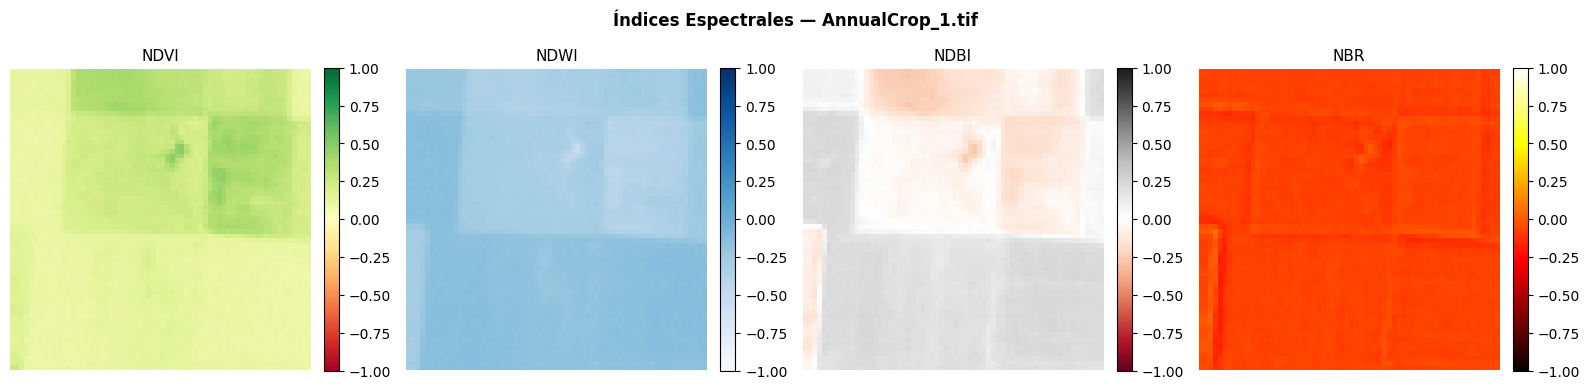

 Guardado: /content/indices_muestra.png


In [ ]:
sample = tif_files[0]
bandas_test = leer_bandas(sample)
indices_test = calcular_indices(bandas_test)

print(f"🔬 Prueba con: {sample.name}\n")
for nombre, arr in indices_test.items():
    print(f"  {nombre}  min={arr.min():.4f}  max={arr.max():.4f}  "
          f"mean={arr.mean():.4f}  shape={arr.shape}")

# Visualización de los 4 índices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colormaps = {"NDVI": "RdYlGn", "NDWI": "Blues", "NDBI": "RdGy", "NBR": "hot"}
fig.suptitle(f"Índices Espectrales — {sample.name}", fontweight='bold')

for ax, (nombre, arr) in zip(axes, indices_test.items()):
    im = ax.imshow(arr, cmap=colormaps[nombre], vmin=-1, vmax=1)
    ax.set_title(nombre, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("/content/indices_muestra.png", dpi=130, bbox_inches='tight')
plt.show()
print(" Guardado: /content/indices_muestra.png")




In [ ]:
# ── CELDA 5: Guardar resultado de UNA imagen ─────────────────────────────────
import os

OUTPUT_DIR = Path("/content/indices_output")
OUTPUT_DIR.mkdir(exist_ok=True)

def guardar_indices(ruta_origen: Path, indices: dict, output_dir: Path):
    """
    Guarda los 4 índices como un solo .tif de 4 bandas (falso color).
    Nombre: <imagen_original>_indices.tif
    """
    nombre_salida = ruta_origen.stem + "_indices.tif"
    ruta_salida   = output_dir / nombre_salida

    # Leer metadata de la imagen original
    with rasterio.open(ruta_origen) as src:
        perfil = src.profile

    # Actualizar perfil para 4 bandas float32
    perfil.update(
        count=4,
        dtype=rasterio.float32,
        compress='lzw'     # compresión sin pérdida → archivos más pequeños
    )

    with rasterio.open(ruta_salida, 'w', **perfil) as dst:
        for i, (nombre, arr) in enumerate(indices.items(), start=1):
            dst.write(arr, i)
            dst.update_tags(i, name=nombre)

    return ruta_salida


ruta_guardada = guardar_indices(sample, indices_test, OUTPUT_DIR)
print(f"✅ Guardado en: {ruta_guardada}")
print(f"   Tamaño: {ruta_guardada.stat().st_size / 1024:.1f} KB")

# Verificar que se puede leer de vuelta
with rasterio.open(ruta_guardada) as check:
    print(f"   Bandas escritas: {check.count}")
    print(f"   Tags banda 1: {check.tags(1)}")


✅ Guardado en: /content/indices_output/AnnualCrop_1_indices.tif
   Tamaño: 73.7 KB
   Bandas escritas: 4
   Tags banda 1: {'name': 'NDVI'}


In [ ]:

OUTPUT_DIR.mkdir(exist_ok=True)

print(f"🔄 Procesando {len(tif_files)} imágenes secuencialmente...")
print("   (Este es el BASELINE lento que vamos a mejorar en Fase 3)\n")

errores    = []
procesadas = 0
t_inicio   = time.time()

# ── para prueba rápida usa tif_files[:100], luego quita el slice ──
for path in tqdm(tif_files, desc="Calculando índices"):
    bandas  = leer_bandas(path)
    if bandas is None:
        errores.append(path.name)
        continue

    indices = calcular_indices(bandas)
    guardar_indices(path, indices, OUTPUT_DIR)
    procesadas += 1

t_total = time.time() - t_inicio

print(f"\n✅ Procesadas : {procesadas}")
print(f"❌ Errores    : {len(errores)}")
print(f"⏱  Tiempo     : {t_total:.1f} seg  ({t_total/60:.1f} min)")
print(f"   Por imagen : {t_total/max(procesadas,1)*1000:.1f} ms")
print(f"\n📁 Resultados en: {OUTPUT_DIR}")
print(f"   Archivos generados: {len(list(OUTPUT_DIR.glob('*.tif')))}")

if errores:
    print(f"\n⚠️  Imágenes con error:")
    for e in errores[:10]:
        print(f"   ✗ {e}")

🔄 Procesando 27000 imágenes secuencialmente...
   (Este es el BASELINE lento que vamos a mejorar en Fase 3)



Se han truncado las últimas 5000 líneas del flujo de salida.
Calculando índices: 100%|██████████| 27000/27000 [18:33<00:00, 24.25it/s]



✅ Procesadas : 27000
❌ Errores    : 0
⏱  Tiempo     : 1113.4 seg  (18.6 min)
   Por imagen : 41.2 ms

📁 Resultados en: /content/indices_output
   Archivos generados: 27000



# GEORISK AI — FASE 3: PROCESAMIENTO PARALELO
# Baseline secuencial: 1113 seg (18.6 min)
# Meta: < 5 min usando Procesos + JIT




In [ ]:
N_CPUS = os.cpu_count()
print(f"CPUs disponibles: {N_CPUS}")
print(f"Baseline a superar: 1113.4 seg (18.6 min)")
print(f"Meta: < 300 seg (5 min)")


⚙️  CPUs disponibles: 2
📦 Baseline a superar: 1113.4 seg (18.6 min)
🎯 Meta: < 300 seg (5 min)


In [ ]:
@njit(parallel=True, cache=True)
def calcular_4_indices_jit(blue, green, red, nir, swir1, swir2):
    """
    Calcula NDVI, NDWI, NDBI, NBR en paralelo píxel a píxel con Numba.
    Entrada : 6 arrays float32 (H, W)
    Salida  : 4 arrays float32 (H, W)

    prange → Numba paraleliza el bucle interno entre los núcleos del CPU.
    """
    H, W = nir.shape
    ndvi  = np.empty((H, W), dtype=np.float32)
    ndwi  = np.empty((H, W), dtype=np.float32)
    ndbi  = np.empty((H, W), dtype=np.float32)
    nbr   = np.empty((H, W), dtype=np.float32)

    for i in prange(H):
        for j in range(W):
            n  = nir[i, j]
            r  = red[i, j]
            g  = green[i, j]
            b  = blue[i, j]
            s1 = swir1[i, j]
            s2 = swir2[i, j]

            # NDVI = (NIR - Red) / (NIR + Red)
            d = n + r
            ndvi[i, j] = (n - r) / d if d != 0.0 else 0.0

            # NDWI = (Green - NIR) / (Green + NIR)
            d = g + n
            ndwi[i, j] = (g - n) / d if d != 0.0 else 0.0

            # NDBI = (SWIR1 - NIR) / (SWIR1 + NIR)
            d = s1 + n
            ndbi[i, j] = (s1 - n) / d if d != 0.0 else 0.0

            # NBR  = (NIR - SWIR2) / (NIR + SWIR2)
            d = n + s2
            nbr[i, j]  = (n - s2) / d if d != 0.0 else 0.0

    return ndvi, ndwi, ndbi, nbr


# ── Precalentar JIT (la primera llamada compila, no cuenta como tiempo real) ─
print("Precalentando compilación JIT (solo una vez)...")
_dummy = np.random.rand(64, 64).astype(np.float32)
calcular_4_indices_jit(_dummy, _dummy, _dummy, _dummy, _dummy, _dummy)
print("JIT compilado y listo\n")

Precalentando compilación JIT (solo una vez)...
JIT compilado y listo



In [ ]:
# ── CELDA 3: Función worker (se ejecuta en cada proceso) ─────────────────────
BAND_MAP = {
    "Blue":  1, "Green": 2, "Red": 3,
    "NIR":   7, "SWIR1": 11, "SWIR2": 12,
}
OUTPUT_DIR = Path("/content/indices_output_paralelo")
OUTPUT_DIR.mkdir(exist_ok=True)

def procesar_imagen(args):
    """
    Worker: lee un .tif, calcula los 4 índices, guarda resultado.
    Retorna (nombre, True) si OK, (nombre, False) si error.

    Recibe args = (ruta_str, output_dir_str) para ser serializable entre procesos.
    """
    ruta_str, out_str = args
    path       = Path(ruta_str)
    output_dir = Path(out_str)

    try:
        # ── Lectura ──────────────────────────────────────────────────────────
        with rasterio.open(path) as src:
            raw    = src.read()           # (13, 64, 64) uint16
            perfil = src.profile

        # ── Limpieza (4 reglas del enunciado) ─────────────────────────────
        def banda(idx):
            return np.clip(
                raw[idx].astype(np.float32) / 10_000.0,
                0.0, 1.0
            )

        blue  = banda(BAND_MAP["Blue"])
        green = banda(BAND_MAP["Green"])
        red   = banda(BAND_MAP["Red"])
        nir   = banda(BAND_MAP["NIR"])
        swir1 = banda(BAND_MAP["SWIR1"])
        swir2 = banda(BAND_MAP["SWIR2"])

        # ── Cálculo JIT ───────────────────────────────────────────────────
        ndvi, ndwi, ndbi, nbr = calcular_4_indices_jit(
            blue, green, red, nir, swir1, swir2
        )

        # ── Guardar .tif de 4 bandas ──────────────────────────────────────
        perfil.update(count=4, dtype=rasterio.float32, compress='lzw')
        out_path = output_dir / (path.stem + "_indices.tif")

        with rasterio.open(out_path, 'w', **perfil) as dst:
            for i, (arr, tag) in enumerate(
                zip([ndvi, ndwi, ndbi, nbr],
                    ["NDVI", "NDWI", "NDBI", "NBR"]), start=1
            ):
                dst.write(arr, i)
                dst.update_tags(i, name=tag)

        return (path.name, True, None)

    except Exception as e:
        return (path.name, False, str(e))


In [ ]:
# ── CELDA 4: Lanzar procesamiento paralelo ───────────────────────────────────
DATASET_PATH = Path("/kaggle/input/sentinel-2-satellite-imagery/sentinel_2/ds")
tif_files    = sorted(DATASET_PATH.glob("**/*.tif"))

# Preparar args como strings (necesario para serialización entre procesos)
args_list = [(str(p), str(OUTPUT_DIR)) for p in tif_files]

print(f"Iniciando proceso paralelo")
print(f"Imágenes  : {len(args_list)}")
print(f"Workers   : {N_CPUS} procesos")
print(f"Output    : {OUTPUT_DIR}\n")

procesadas = 0
errores    = []
t_inicio   = time.time()

with ProcessPoolExecutor(max_workers=N_CPUS) as executor:
    futuros = {executor.submit(procesar_imagen, a): a for a in args_list}

    for futuro in tqdm(as_completed(futuros), total=len(futuros),
                       desc="Procesando"):
        nombre, ok, err = futuro.result()
        if ok:
            procesadas += 1
        else:
            errores.append({"archivo": nombre, "error": err})

t_total = time.time() - t_inicio


# ── CELDA 5: Reporte de resultados y speedup ─────────────────────────────────
BASELINE = 1113.4   # segundos — tu medición secuencial

print("\n" + "═" * 50)
print("  REPORTE FINAL — FASE 3: Procesamiento paralelo")
print("═" * 50)
print(f"Imágenes procesadas : {procesadas:,}")
print(f"Errores             : {len(errores)}")
print(f"Tiempo paralelo     : {t_total:.1f} seg  ({t_total/60:.1f} min)")
print(f"Por imagen          : {t_total/max(procesadas,1)*1000:.1f} ms")
print(f"Archivos generados  : {len(list(OUTPUT_DIR.glob('*.tif'))):,}")
print("─" * 50)
print(f"Baseline (sec.)  : {BASELINE:.1f} seg")
print(f"Paralelo         : {t_total:.1f} seg")
speedup = BASELINE / t_total
print(f"Rapidez          : {speedup:.2f}x más rápido")
print(f"Tiempo ahorrado  : {(BASELINE - t_total)/60:.1f} minutos")
print("═" * 50)

if errores:
    print(f"\n⚠️  Errores (primeros 5):")
    for e in errores[:5]:
        print(f"   ✗ {e['archivo']} → {e['error']}")


Iniciando proceso paralelo
Imágenes  : 27000
Workers   : 2 procesos
Output    : /content/indices_output_paralelo



Se han truncado las últimas 5000 líneas del flujo de salida.
Procesando: 100%|██████████| 27000/27000 [11:53<00:00, 37.83it/s]



══════════════════════════════════════════════════
  REPORTE FINAL — FASE 3: Procesamiento paralelo
══════════════════════════════════════════════════
Imágenes procesadas : 27,000
Errores             : 0
Tiempo paralelo     : 715.2 seg  (11.9 min)
Por imagen          : 26.5 ms
Archivos generados  : 27,000
──────────────────────────────────────────────────
Baseline (sec.)  : 1113.4 seg
Paralelo         : 715.2 seg
Rapidez          : 1.56x más rápido
Tiempo ahorrado  : 6.6 minutos
══════════════════════════════════════════════════


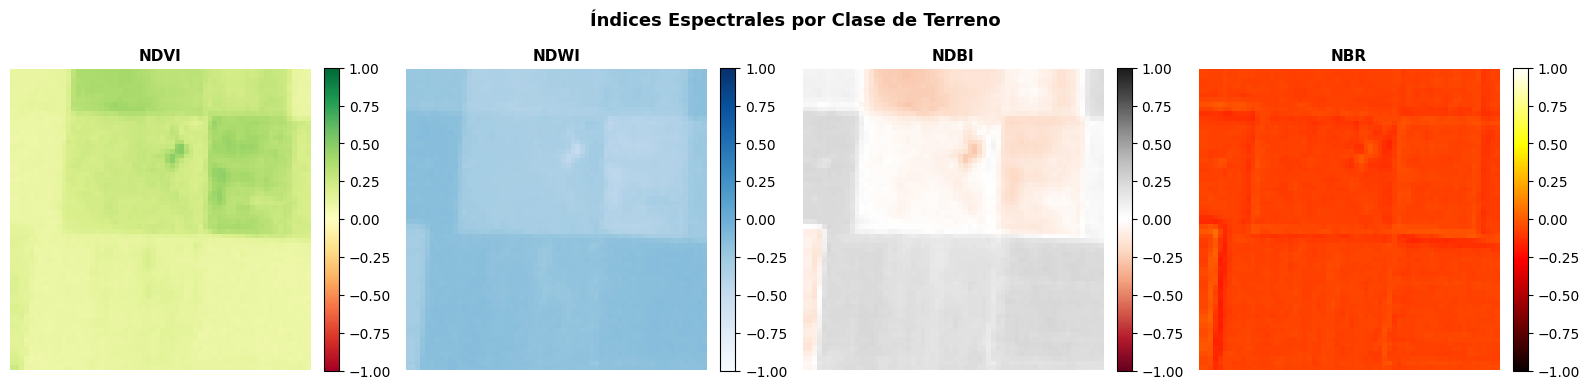

💾 Guardado: /content/indices_por_clase.png
🎉 PROYECTO COMPLETADO


In [ ]:


OUTPUT_DIR = Path("/content/indices_output_paralelo")

clases_ejemplo = {}
for f in tif_files[:500]:
    clase = f.stem.rsplit('_', 1)[0]
    if clase not in clases_ejemplo:
        clases_ejemplo[clase] = f
    if len(clases_ejemplo) >= 4:
        break

n_clases        = len(clases_ejemplo)
indices_nombres = ["NDVI", "NDWI", "NDBI", "NBR"]
colormaps       = ["RdYlGn", "Blues", "RdGy", "hot"]

fig, axes = plt.subplots(n_clases, 4, figsize=(16, 4 * n_clases))

# ── FIX: forzar siempre array 2D ─────────────────────────────────────────────
axes = np.array(axes).reshape(n_clases, 4)

for row, (clase, path) in enumerate(clases_ejemplo.items()):
    out_path = OUTPUT_DIR / (path.stem + "_indices.tif")
    with rasterio.open(out_path) as src:
        data = src.read()   # (4, 64, 64)

    for col, (nombre, cmap) in enumerate(zip(indices_nombres, colormaps)):
        ax = axes[row][col]
        im = ax.imshow(data[col], cmap=cmap, vmin=-1, vmax=1)
        if row == 0:
            ax.set_title(nombre, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(clase, fontsize=10, rotation=45, labelpad=40)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Índices Espectrales por Clase de Terreno", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/indices_por_clase.png", dpi=130, bbox_inches='tight')
plt.show()
print("💾 Guardado: /content/indices_por_clase.png")
print("🎉 PROYECTO COMPLETADO")

Clases encontradas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


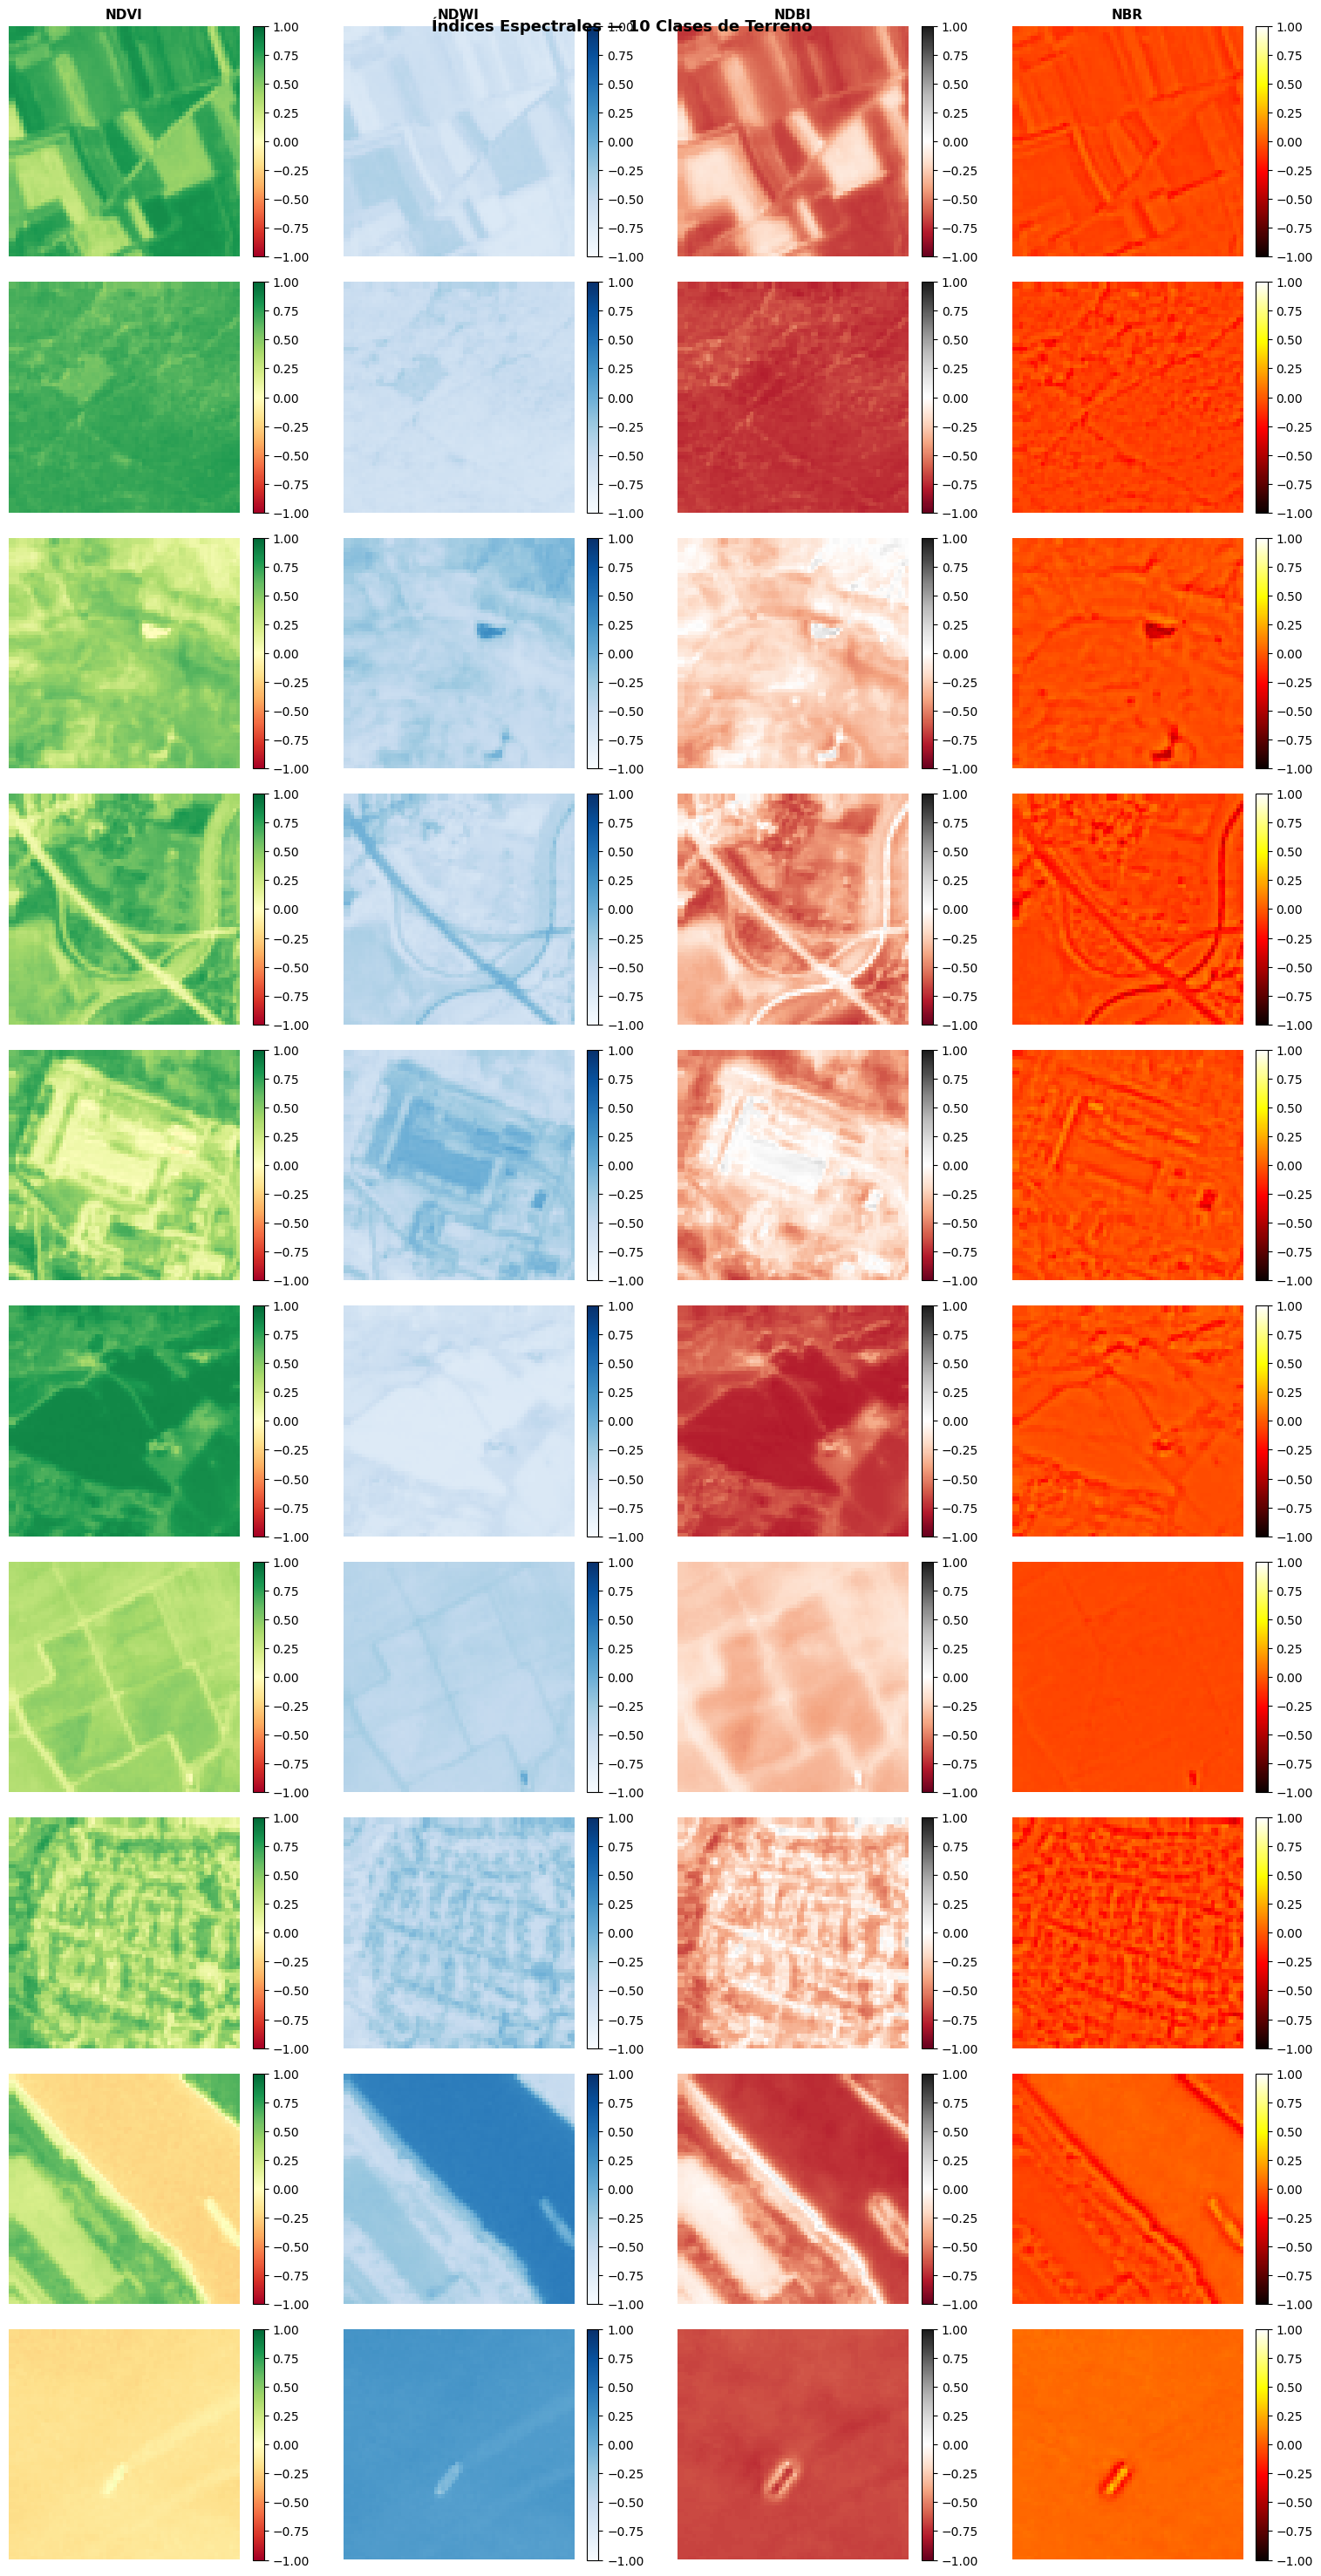

💾 Guardado: /content/indices_10_clases.png


In [ ]:
# ── Tomar 1 imagen de cada clase directamente ────────────────────────────────
OUTPUT_DIR = Path("/content/indices_output_paralelo")

# Las 10 clases del dataset EuroSAT
CLASES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]

# Tomar el primer archivo procesado de cada clase
clases_ejemplo = {}
for clase in CLASES:
    candidatos = list(OUTPUT_DIR.glob(f"{clase}_*_indices.tif"))
    if candidatos:
        clases_ejemplo[clase] = candidatos[0]

print(f"Clases encontradas: {list(clases_ejemplo.keys())}")

# ── Visualizar ────────────────────────────────────────────────────────────────
n_clases        = len(clases_ejemplo)
indices_nombres = ["NDVI", "NDWI", "NDBI", "NBR"]
colormaps       = ["RdYlGn", "Blues", "RdGy", "hot"]

fig, axes = plt.subplots(n_clases, 4, figsize=(16, 3 * n_clases))
axes = np.array(axes).reshape(n_clases, 4)

for row, (clase, out_path) in enumerate(clases_ejemplo.items()):
    with rasterio.open(out_path) as src:
        data = src.read()

    for col, (nombre, cmap) in enumerate(zip(indices_nombres, colormaps)):
        ax = axes[row][col]
        im = ax.imshow(data[col], cmap=cmap, vmin=-1, vmax=1)
        if row == 0:
            ax.set_title(nombre, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(clase, fontsize=8, rotation=30, labelpad=50, ha='right')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Índices Espectrales — 10 Clases de Terreno", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/indices_10_clases.png", dpi=120, bbox_inches='tight')
plt.show()
print("💾 Guardado: /content/indices_10_clases.png")

# GEORISK AI — FASE 3 OPTIMIZADA: Batches + Threads
# Problema anterior: ProcessPoolExecutor tiene overhead alto para
# imágenes pequeñas (64×64). El cuello de botella es I/O, no CPU.
# Solución: ThreadPoolExecutor + procesar en lotes de N imágenes por worker



In [ ]:
DATASET_PATH = Path("/kaggle/input/sentinel-2-satellite-imagery/sentinel_2/ds")
OUTPUT_DIR   = Path("/content/indices_output_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

tif_files = sorted(DATASET_PATH.glob("**/*.tif"))
N_CPUS    = os.cpu_count()
BASELINE  = 1113.4

BAND_MAP = {"Blue":1, "Green":2, "Red":3, "NIR":7, "SWIR1":11, "SWIR2":12}

print(f"⚙️  CPUs: {N_CPUS}  |  Imágenes: {len(tif_files):,}")
print(f"📦 Baseline a superar: {BASELINE} seg")



⚙️  CPUs: 2  |  Imágenes: 27,000
📦 Baseline a superar: 1113.4 seg


In [ ]:
# ── CELDA 2: JIT compilado ────────────────────────────────────────────────────
@njit(parallel=True, cache=True)
def calcular_4_indices_jit(blue, green, red, nir, swir1, swir2):
    H, W  = nir.shape
    ndvi  = np.empty((H, W), dtype=np.float32)
    ndwi  = np.empty((H, W), dtype=np.float32)
    ndbi  = np.empty((H, W), dtype=np.float32)
    nbr   = np.empty((H, W), dtype=np.float32)
    for i in prange(H):
        for j in range(W):
            n=nir[i,j]; r=red[i,j]; g=green[i,j]
            b=blue[i,j]; s1=swir1[i,j]; s2=swir2[i,j]
            d=n+r;  ndvi[i,j]=(n-r)/d if d!=0. else 0.
            d=g+n;  ndwi[i,j]=(g-n)/d if d!=0. else 0.
            d=s1+n; ndbi[i,j]=(s1-n)/d if d!=0. else 0.
            d=n+s2; nbr[i,j] =(n-s2)/d if d!=0. else 0.
    return ndvi, ndwi, ndbi, nbr

# Precalentar
_d = np.random.rand(64,64).astype(np.float32)
calcular_4_indices_jit(_d,_d,_d,_d,_d,_d)
print("✅ JIT listo")


✅ JIT listo


In [ ]:
# ── CELDA 3: Worker que procesa un LOTE de imágenes ───────────────────────────
# Clave: abrir/cerrar N archivos por llamada → amortiza overhead de threads

def procesar_lote(rutas: list[Path]) -> tuple[int, int]:
    """
    Procesa un lote de imágenes en el mismo hilo.
    Retorna (ok, errores).
    """
    ok = err = 0
    for path in rutas:
        try:
            with rasterio.open(path) as src:
                raw    = src.read()
                perfil = src.profile

            def b(idx):
                return np.clip(
                    raw[idx].astype(np.float32) / 10_000.0, 0., 1.)

            ndvi, ndwi, ndbi, nbr = calcular_4_indices_jit(
                b(1), b(2), b(3), b(7), b(11), b(12))

            perfil.update(count=4, dtype=rasterio.float32, compress='lzw')
            out = OUTPUT_DIR / (path.stem + "_indices.tif")

            with rasterio.open(out, 'w', **perfil) as dst:
                for i, (arr, tag) in enumerate(
                    zip([ndvi,ndwi,ndbi,nbr],
                        ["NDVI","NDWI","NDBI","NBR"]), 1):
                    dst.write(arr, i)
                    dst.update_tags(i, name=tag)
            ok += 1

        except Exception:
            err += 1

    return ok, err


In [ ]:
# ── CELDA 4: Benchmark de tamaño de lote ─────────────────────────────────────
# Probamos 3 tamaños para encontrar el óptimo en este entorno

print("🔬 Buscando tamaño de lote óptimo (muestra de 300 imágenes)...\n")

muestra  = tif_files[:300]
opciones = [10, 50, 100]
mejores  = {}

for tam in opciones:
    lotes = [muestra[i:i+tam] for i in range(0, len(muestra), tam)]
    t0    = time.time()
    total_ok = 0
    with ThreadPoolExecutor(max_workers=N_CPUS*2) as ex:
        for ok, _ in ex.map(procesar_lote, lotes):
            total_ok += ok
    t = time.time() - t0
    ms_img = t / total_ok * 1000
    mejores[tam] = ms_img
    print(f"  Lote={tam:3d} imgs → {t:.1f}s  |  {ms_img:.1f} ms/img")

MEJOR_LOTE = min(mejores, key=mejores.get)
print(f"\n🏆 Mejor tamaño de lote: {MEJOR_LOTE} imágenes")


🔬 Buscando tamaño de lote óptimo (muestra de 300 imágenes)...



  Lote= 10 imgs → 9.5s  |  31.7 ms/img


  Lote= 50 imgs → 4.5s  |  15.1 ms/img


  Lote=100 imgs → 4.0s  |  13.5 ms/img

🏆 Mejor tamaño de lote: 100 imágenes


In [ ]:
# ── CELDA 5: Procesamiento paralelo COMPLETO con lote óptimo ─────────────────
print(f"\n Procesando 27,000 imágenes")
print(f"   Lote   : {MEJOR_LOTE} imágenes/worker")
print(f"   Threads: {N_CPUS*2}\n")

lotes      = [tif_files[i:i+MEJOR_LOTE]
              for i in range(0, len(tif_files), MEJOR_LOTE)]
total_ok   = total_err = 0
t_inicio   = time.time()

with ThreadPoolExecutor(max_workers=N_CPUS*2) as executor:
    futuros = [executor.submit(procesar_lote, lote) for lote in lotes]
    for fut in tqdm(as_completed(futuros), total=len(futuros),
                    desc=" Lotes"):
        ok, err = fut.result()
        total_ok  += ok
        total_err += err

t_total = time.time() - t_inicio



 Procesando 27,000 imágenes
   Lote   : 100 imágenes/worker
   Threads: 4



Se han truncado las últimas 5000 líneas del flujo de salida.
 Lotes: 100%|██████████| 270/270 [12:11<00:00,  2.71s/it]


In [ ]:
# ── CELDA 6: Reporte comparativo ─────────────────────────────────────────────
v1_tiempo  = 715.2    # ProcessPoolExecutor (resultado anterior)

print("\n" + "═"*52)
print("  📊  COMPARATIVA DE ESTRATEGIAS")
print("═"*52)
print(f"  {'Estrategia':<28} {'Tiempo':>8}  {'Speedup':>8}")
print("─"*52)
print(f"  {'Secuencial (baseline)':<28} {BASELINE:>7.1f}s  {'1.00x':>8}")
print(f"  {'ProcessPoolExecutor (v1)':<28} {v1_tiempo:>7.1f}s  {BASELINE/v1_tiempo:>7.2f}x")
print(f"  {'ThreadPool + Lotes (v2)':<28} {t_total:>7.1f}s  {BASELINE/t_total:>7.2f}x")
print("═"*52)
print(f"\n  Imágenes procesadas : {total_ok:,}")
print(f"  Errores             : {total_err}")
print(f"  Tiempo              : {t_total:.1f} seg  ({t_total/60:.1f} min)")
print(f"  Por imagen          : {t_total/max(total_ok,1)*1000:.1f} ms")
print(f"  Speedup final       : {BASELINE/t_total:.2f}x")
print(f"  Tiempo ahorrado     : {(BASELINE-t_total)/60:.1f} minutos")



════════════════════════════════════════════════════
  📊  COMPARATIVA DE ESTRATEGIAS
════════════════════════════════════════════════════
  Estrategia                     Tiempo   Speedup
────────────────────────────────────────────────────
  Secuencial (baseline)         1113.4s     1.00x
  ProcessPoolExecutor (v1)       715.2s     1.56x
  ThreadPool + Lotes (v2)        732.3s     1.52x
════════════════════════════════════════════════════

  Imágenes procesadas : 27,000
  Errores             : 0
  Tiempo              : 732.3 seg  (12.2 min)
  Por imagen          : 27.1 ms
  Speedup final       : 1.52x
  Tiempo ahorrado     : 6.4 minutos


# Descarga de los datos, se usara una API para poder traerlos


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gallo33henrique/sentinel-2-satellite-imagery")

print("Path to dataset files:", path)

Resuming download from 1932525568 bytes (232456459 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/gallo33henrique/sentinel-2-satellite-imagery/1.archive (1932525568/2164982027) bytes left.


100%|██████████| 2.02G/2.02G [00:01<00:00, 117MB/s]

Extracting files...
